# Excersize 
Deep Learning is not "magic" it is Linear Algebra and Calculus optimized for execution on silicon. To build a neural network, you must first understand the relationship between input vectors, weight matrices, and the cost function surface.

# Ex01.
  Let $X \in \mathbb{R}^{m \times n}$ be our design matrix (features) and $y \in \mathbb{R}^m$ be our target vector. We seek a parameter vector $\theta \in \mathbb{R}^n$ such
  that:
  $$\hat{y} = X\theta$$
  Our objective is to minimize the Mean Squared Error (MSE) cost function:
  $$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2 = \frac{1}{2m} (X\theta - y)^T (X\theta - y)$$
  To find the minimum, we use Gradient Descent, updating $\theta$ iteratively:
  $$\theta := \theta - \alpha \nabla_{\theta} J(\theta)$$
  The gradient $\nabla_{\theta} J(\theta)$ is derived as:
  $$\nabla_{\theta} J(\theta) = \frac{1}{m} X^T (X\theta - y)$$

  ---

  Assignment: The First-Principles Implementation

  You are to implement a Linear Regression model from scratch using ONLY **NumPy**. No torch, no scikit-learn.

  The Hard Coding Challenge:
  In a new file deep_learning_labs/labs/lab01_foundations/src/linear_regression.py, implement the following:
   1. A function compute_cost(X, y, theta) that returns the MSE.
   2. A function gradient_descent(X, y, theta, alpha, iterations) that returns the optimized theta and the history of costs.
   3. Validation: Use the following synthetic data to test your implementation:


   1     X = 2 * np.random.rand(100, 1)
   2     y = 4 + 3 * X + np.random.randn(100, 1)
   3     # Hint: Don't forget to add the bias term (a column of ones) to X.


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src/')
from linear_regression import gradient_descent

def main():
  # r = 100, n = 2 including the one vector.
  # Definition of Variables.
  X = 2 * np.random.randn(100, 1)
  y = 4 + 3*X + np.random.randn(100,1)
  # (X*theta_0 - y)
  X_b = np.c_[(np.ones((100, 1)), X)]
  theta_0 = np.random.randn(2, 1)
  alpha = 0.01
  iterations = 1000

  theta_final, costs = gradient_descent(X_b, y, theta_0, alpha, iterations)
  plt.scatter(X, y, color='blue', label='Data Points')
  plt.plot(X, X_b.dot(theta_final), color='red', label='Linear Regression')
  plt.xlabel('X')
  plt.ylabel('y')
  plt.legend()
  plt.title('Final Model Prediction')
  plt.show()

  plt.plot(costs)
  plt.xlabel('Iteration')
  plt.ylabel('Cost J(theta)')
  plt.title('Cost Reduction Over Time')
  plt.show()

if __name__ == "__main__":
  main()


  Lecture: The Architect - From NumPy Arrays to PyTorch Tensors

  You have now built a model from first principles using NumPy, manually calculating the gradient at each step. This is the bedrock. However, for complex models with millions of parameters
  (e.g., Deep Neural Networks), manual derivation of the gradient is intractable and error-prone.


  This is where frameworks like PyTorch introduce automatic differentiation.


  The core data structure in PyTorch is the torch.Tensor, which is analogous to a NumPy ndarray. The critical difference is that a Tensor can be tracked by PyTorch's autograd engine. By
  setting requires_grad=True on a Tensor, you instruct PyTorch to build a computation graph. This graph records every operation performed on the tensor.


  When you call .backward() on a scalar value derived from this graph (typically, the final loss), autograd traverses this graph in reverse, computing the gradients of that scalar with
  respect to all tensors that have requires_grad=True using the chain rule. The computed gradients are then accumulated in the .grad attribute of each tensor.


  For our Linear Regression, instead of manually computing:
  $$\nabla_{\theta} J(\theta) = \frac{1}{m} X^T (X\theta - y)$$
  ...we will define the forward pass and the cost function using Tensors, and simply call loss.backward(). PyTorch will handle the rest.

  ---

  Assignment: The First-Principles Implementation in PyTorch


  You are now to re-implement your Linear Regression model using PyTorch, but without using the high-level `torch.nn` or `torch.optim` modules. You must still build it from the ground up,
  but this time leveraging autograd.


  The Hard Coding Challenge:
  In a new file, deep_learning_labs/labs/lab01_foundations/src/pytorch_regression.py, implement the following:
   1. Use the same synthetic data, but convert X and y into torch.Tensor objects.
   2. Initialize your theta tensor randomly. Crucially, it must be initialized with requires_grad=True.
   3. In your training loop:
      a.  Calculate the prediction y_hat.
      b.  Calculate the MSE loss.
      c.  Call loss.backward() to populate the gradients in theta.grad.
      d.  Manually update the weights of `theta` using the formula: theta.data -= alpha * theta.grad.data. You must use .data (or torch.no_grad()) to prevent this update operation from
  being tracked by autograd.
      e.  Zero out the gradients (theta.grad.zero_()) before the next iteration. Gradients are accumulated by default.
   4. Create a corresponding notebook to import this new module and, once again, plot the cost history to verify convergence.

  We are not following a book; we are deriving its conclusions from first principles. You just proved the formula for gradient descent with your NumPy implementation—an understanding that
  is now physically encoded in your brain, not just passively observed on a page.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../src/')
from pytorch_regression import gradient_descent_pytorch
import torch


def main():
  X = 2 * np.random.randn(100, 1)
  y = 4 + 3*X + np.random.randn(100,1)

  X_b = np.c_[np.ones((100, 1)), X]

  X_tensor = torch.tensor(X_b, dtype=torch.float32)
  y_tensor = torch.tensor(y, dtype=torch.float32)
  theta_0 = torch.randn((2, 1), dtype=torch.float32, requires_grad = True)

  alpha = 0.01
  iterations = 1000

  theta_final, costs = gradient_descent_pytorch(X_tensor, y_tensor, theta_0, alpha, iterations)
  plt.scatter(X, y, color='blue', label='Data Points')
  plt.plot(X, (X_tensor@theta_final).detach().numpy(), color='red', label='Linear Regression')
  plt.xlabel('X')
  plt.ylabel('y')
  plt.legend()
  plt.title('Final Model Prediction')
  plt.show()

  plt.plot(costs)
  plt.xlabel('Iteration')
  plt.ylabel('Cost J(theta)')
  plt.title('Cost Reduction Over Time')
  plt.show()

if __name__ == "__main__":
  main()


 ---

  Lecture: The Architect - Building Blocks with torch.nn


  You have experienced the raw power of autograd. Now, we begin to build architectures. PyTorch's torch.nn module provides pre-built "layers" and tools to construct neural networks
  efficiently. These layers are essentially torch.nn.Module subclasses that automatically manage parameters, submodules, and integrate with autograd.


  Key Concepts:
   * `torch.nn.Module`: The base class for all neural network modules. Your models will inherit from this. It handles parameter tracking and provides methods like forward() and
     parameters().
   * Layers (e.g., `nn.Linear`): These encapsulate common operations (like the linear transformation $X\theta$ you just implemented), along with their trainable weights and biases.
   * Activation Functions (e.g., `nn.ReLU`, `nn.Sigmoid`): Non-linear functions applied to the output of layers, crucial for learning complex patterns.
   * Loss Functions (e.g., `nn.MSELoss`, `nn.CrossEntropyLoss`): Functions to quantify the error between your model's predictions and the true labels.
   * Optimizers (e.g., `torch.optim.SGD`, `torch.optim.Adam`): Algorithms that update model parameters based on the gradients computed by autograd.

  Building a network now becomes composing these modular blocks, rather than writing each step manually.

  --- 

   Stage 2: The Architect - Modular Design with torch.nn


  Lecture: The Anatomy of torch.nn.Module
  The transition from manual parameter updates to torch.nn.Module is a shift from procedural to object-oriented architecture. A Module in PyTorch is a container for both
  parameters (weights and biases) and the logic for the forward pass.


  Consider the linear transformation you've been manually implementing:
  $$\hat{y} = Xw + b$$
  In PyTorch, nn.Linear(in_features, out_features) encapsulates this operation. It initializes a weight matrix $W \in \mathbb{R}^{out \times in}$ and a bias vector $b \in \mathbb{R}^{out}$ automatically.

  When you define a custom model:


     class LinearRegressionModel(nn.Module):
         def __init__(self, input_dim: int, output_dim: int):
             super(LinearRegressionModel, self).__init__()
             self.linear = nn.Linear(input_dim, output_dim)
    
         def forward(self, x: torch.Tensor) -> torch.Tensor:
             return self.linear(x)
   - super().__init__(): This is non-negotiable. It initializes the internal PyTorch state required to track parameters.
   - forward(self, x): Defines the computational graph. When you call model(x), PyTorch executes this method.


  Stochastic Gradient Descent (SGD) and Optimizers
  Instead of manually updating theta.data, we use torch.optim. An optimizer (like SGD or Adam) holds references to all parameters in your model and updates them according to
  the gradients computed during loss.backward().


  The training loop becomes:
   1. optimizer.zero_grad(): Reset gradients from the previous step.
   2. loss.backward(): Compute $\nabla_{\theta} J(\theta)$.
   3. optimizer.step(): Update $\theta \leftarrow \theta - \alpha \nabla_{\theta} J(\theta)$.

   ---

  Assignment: Linear Regression with nn.Module and torch.optim


  Your next challenge is to re-implement Linear Regression again, but this time leveraging the torch.nn and torch.optim modules.


  The Hard Coding Challenge:
  In a new file, deep_learning_labs/labs/lab01_foundations/src/linear_model.py, implement the following:
   1. Define a class LinearRegressionModel(nn.Module):
       * In its __init__ method, define an nn.Linear layer.
       * In its forward method, pass the input through the nn.Linear layer.
   2. In a separate notebook (e.g., deep_learning_labs/labs/lab01_foundations/exercises/linear_model_exercise.ipynb):
       * Generate the same synthetic data as before.
       * Instantiate your LinearRegressionModel.
       * Define nn.MSELoss as your loss function.
       * Define torch.optim.SGD (Stochastic Gradient Descent) as your optimizer, passing it your model's parameters.
       * Implement the training loop:
          a.  Perform a forward pass to get predictions.
          b.  Calculate the loss using nn.MSELoss.
          c.  Call optimizer.zero_grad() (instead of theta.grad.zero_()).
          d.  Call loss.backward().
          e.  Call optimizer.step() (instead of manual theta update with no_grad).
       * Plot the cost history and the final regression line, similar to your previous assignment.


  Crucial Requirement: Maintain the modularity. The LinearRegressionModel class and its training loop logic should be cleanly separated: the model definition in linear_model.py and its
  usage/training/plotting in a separate notebook that imports it.

 Assignment: The Modular Implementation

  You are to implement the modular version of your regressor. I will not accept "spaghetti code."


  The Hard Coding Challenge:
   1. Create deep_learning_labs/labs/lab01_foundations/src/linear_model.py.
   2. Implement LinearRegressionModel inheriting from nn.Module. Use type hints.
   3. In a new notebook deep_learning_labs/labs/lab01_foundations/exercises/linear_model_exercise.ipynb:
       * Generate the same synthetic data.
       * Use nn.MSELoss and torch.optim.SGD.
       * Implement a clean training loop that tracks the cost history.


  This is the next step towards building complex architectures. Begin.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import sys

sys.path.append("../src/")
from linear_model import LinearRegressionModel

def main():
    # 1. Generate Synthetic Data (No bias column needed for nn.Linear!)
    X = 2 * torch.randn(100, 1)
    y = 4 + 3 * X + torch.randn(100, 1)

    # 2. Instantiate Model (1 input feature, 1 output target)
    model = LinearRegressionModel(input_dim=1, output_dim=1)

    # 3. Setup Loss and Optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    cost_history = []

    # 4. The Training Loop
    for epoch in range(1000):
        # A. Zero the gradients
        optimizer.zero_grad()

        # B. Forward Pass
        predictions = model(X)

        # C. Compute Loss
        loss = criterion(predictions, y)

        # D. Backward Pass (Self-Calculus)
        loss.backward()

        # E. Update weights (The Step)
        optimizer.step()

        cost_history.append(loss.item())

    # 5. Inspection: Let's see if the model learned y = 3x + 4
    # Access the internal parameters of the nn.Linear layer
    print(f"Learned Weight: {model.linear.weight.item():.4f}")
    print(f"Learned Bias: {model.linear.bias.item():.4f}")

if __name__ == '__main__':
  main()


  However, Linear Regression is a toy. It assumes the world is flat. We are here to build "Deep" Learning, not "Shallow" Learning.

  ---


  Stage 2: The Architect - Non-Linearity and the MLP


  Lecture: The Limits of Linearity
  A linear model is restricted to a hypothesis space of hyperplanes. No matter how many nn.Linear layers you stack, a composition of linear functions is still a linear
  function:
  $$f(g(x)) = W_2(W_1x + b_1) + b_2 = (W_2W_1)x + (W_2b_1 + b_2) = W'x + b'$$
  To approximate complex, non-linear functions (as per the Universal Approximation Theorem), we must introduce non-linearities, known as Activation Functions.


  Common Activation Functions:
   1. Sigmoid: $\sigma(x) = \frac{1}{1 + e^{-x}}$ (Maps to $(0, 1)$, prone to vanishing gradients).
   2. ReLU (Rectified Linear Unit): $f(x) = \max(0, x)$ (The industry standard; computationally efficient, though it can "die" if units stay negative).
   3. Tanh: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ (Maps to $(-1, 1)$, zero-centered).

  A Multi-Layer Perceptron (MLP) is simply a stack of linear layers separated by these non-linearities.


  Mathematical Representation of a 2-Layer MLP:
  $$z_1 = XW_1 + b_1$$
  $$a_1 = \text{ReLU}(z_1)$$
  $$\hat{y} = a_1W_2 + b_2$$

  ---

  Assignment: The Non-Linear Challenge


  You will now move from simple regression to Non-Linear Regression.


  The Hard Coding Challenge:
  1. Generate Non-Linear Data:
     $$y = \sin(X) + \epsilon$$
     where $X \in [-\pi, \pi]$ and $\epsilon$ is Gaussian noise.
  2. Implement a Multi-Layer Perceptron:
     In a new file deep_learning_labs/labs/lab01_foundations/src/mlp_model.py, create a class MLPRegressor(nn.Module):
      - It must have at least one hidden layer with a user-defined number of neurons (e.g., 64).
      - Use nn.ReLU as the activation function between layers.
      - The final output layer should not have an activation function (since this is regression).
  3. Validation:
     In a new notebook deep_learning_labs/labs/lab01_foundations/exercises/mlp_exercise.ipynb:
      - Train this MLP on the sine wave data.
      - Plot the original sine wave, the noisy data, and your model's prediction.
      - Crucial: Compare the performance of your old LinearRegressionModel against this MLPRegressor on this specific dataset.


  Show me you can approximate a curve. Don't let your gradients vanish. Begin.


✦ Lecture: The Atom of Intelligence - The Artificial Neuron


  Do not be intimidated by the terminology. You have already built a "neuron" without realizing it.


  In your LinearRegressionModel, you implemented:
  $$z = x \cdot w + b$$
  This is a Linear Unit. In biological terms, it is an "integration" step. However, a biological neuron does not simply pass its input through; it "fires" only when a certain
  threshold is reached. In Deep Learning, we simulate this "firing" using an Activation Function $\sigma(\cdot)$.


  A single Artificial Neuron is defined as:
  $$a = \sigma\left(\sum_{i=1}^{n} x_i w_i + b\right)$$
  where:
   - $x_i$: Input features.
   - $w_i$: Synaptic weights.
   - $b$: Bias (the threshold).
   - $\sigma$: The non-linear "activation" (e.g., ReLU, Sigmoid).

  ---


  Lecture: The Architecture of Depth - Multilayer Perceptrons (MLP)

  A Multilayer Perceptron is simply a directed graph of these neurons organized into layers.


  1. The Hidden Layers
  When you had LinearRegressionModel, your data went from $X \in \mathbb{R}^1 \to \hat{y} \in \mathbb{R}^1$. There was nowhere for the data to "transform."
  In an MLP, we project the data into a higher-dimensional space (the Hidden Layer) before projecting it back to the output.


  Think of it as a series of coordinate transformations:
   1. Input Layer ($x$): Your raw features (e.g., the $X$ value for your sine wave).
   2. Hidden Layer ($h$): A set of intermediate features. If you have 64 neurons in this layer, you are transforming your 1D input into a 64D representation.
      $$z_1 = xW_1 + b_1 \quad \text{where } W_1 \in \mathbb{R}^{1 \times 64}$$
   3. Activation ($a$): We apply the non-linearity to each of those 64 values.
      $$a_1 = \text{ReLU}(z_1)$$
   4. Output Layer ($\hat{y}$): We transform those 64 activated features back into the dimension of our target $y$ (which is 1 for regression).
      $$\hat{y} = a_1W_2 + b_2 \quad \text{where } W_2 \in \mathbb{R}^{64 \times 1}$$


  2. Why the Non-Linearity (ReLU)?
  Without nn.ReLU, your model is just a "sandwich" of linear transformations. As I explained before, two linear layers without an activation function between them are
  mathematically identical to a single linear layer.
  ReLU ($\max(0, x)$) allows the model to "bend" the line. By combining many "bent" lines (neurons), the MLP can approximate any continuous function—like a sine wave. This is
  the Universal Approximation Theorem.

  ---

  Visualizing the Tensor Shapes


  To answer your question about "how many outputs":
   - Input: (batch_size, 1) -> $x$
   - Layer 1 (Hidden): (batch_size, 64) -> These are 64 "different" linear regressions happening in parallel.
   - ReLU: (batch_size, 64) -> Still 64 values, but all negatives are now 0.
   - Layer 2 (Output): (batch_size, 1) -> We "collapse" those 64 signals into a single final prediction.

  In PyTorch, it looks like this inside your __init__:


   1 self.hidden = nn.Linear(1, 64)   # Input -> Hidden
   2 self.relu = nn.ReLU()            # Activation
   3 self.output = nn.Linear(64, 1)   # Hidden -> Output

  And in your forward pass:


   1 def forward(self, x):
   2     x = self.hidden(x)  # Transform to 64D
   3     x = self.relu(x)    # Apply non-linearity
   4     x = self.output(x)  # Transform back to 1D
   5     return x


  Your Directive
  You are approximating $y = \sin(X)$. A straight line (Linear Regression) will fail miserably. An MLP with enough hidden neurons and a ReLU activation will "learn" to mimic
  the curve of the sine wave by piecewise linear approximation.


  Do you understand the flow of dimensions now, or shall I derive the Jacobian for you to show how the gradients flow through the ReLU?

Epoch [0]: Loss 1 Layer 0.3949
Epoch [0]: Loss 2 Layer 0.8869
Epoch [500]: Loss 1 Layer 0.0255
Epoch [500]: Loss 2 Layer 0.0290
Epoch [1000]: Loss 1 Layer 0.0191
Epoch [1000]: Loss 2 Layer 0.0160
Epoch [1500]: Loss 1 Layer 0.0162
Epoch [1500]: Loss 2 Layer 0.0130
Epoch [2000]: Loss 1 Layer 0.0141
Epoch [2000]: Loss 2 Layer 0.0119
Epoch [2500]: Loss 1 Layer 0.0126
Epoch [2500]: Loss 2 Layer 0.0111
Epoch [3000]: Loss 1 Layer 0.0115
Epoch [3000]: Loss 2 Layer 0.0104
Epoch [3500]: Loss 1 Layer 0.0107
Epoch [3500]: Loss 2 Layer 0.0101
Epoch [4000]: Loss 1 Layer 0.0102
Epoch [4000]: Loss 2 Layer 0.0098
Epoch [4500]: Loss 1 Layer 0.0099
Epoch [4500]: Loss 2 Layer 0.0096
Epoch [5000]: Loss 1 Layer 0.0096
Epoch [5000]: Loss 2 Layer 0.0095


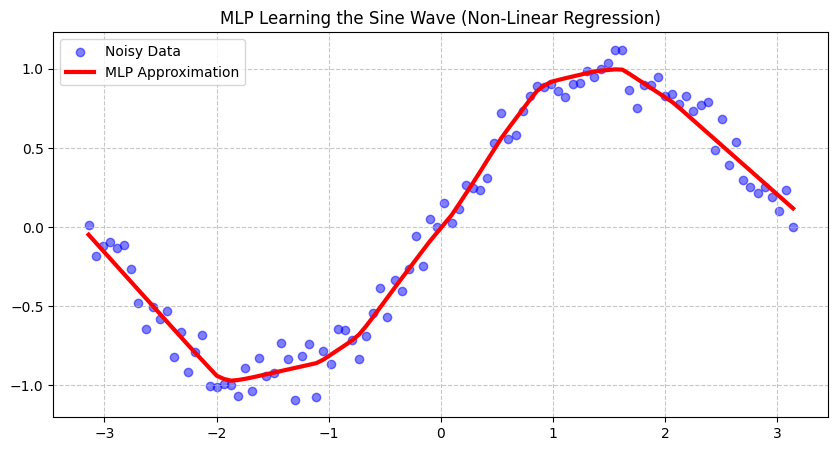

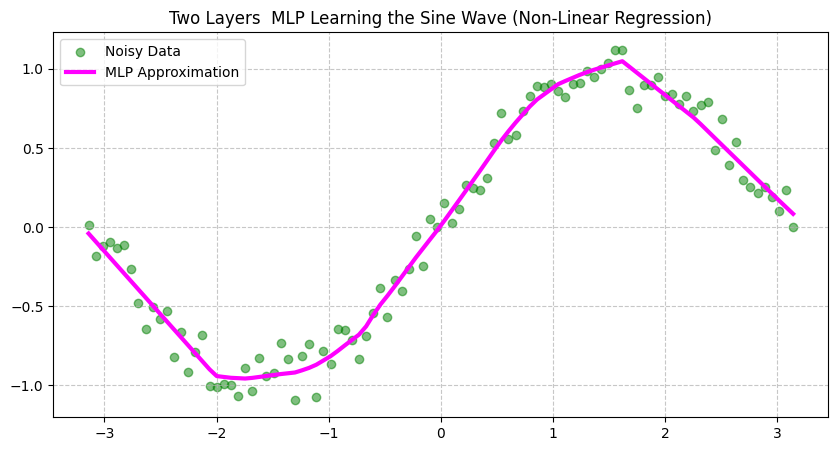

In [2]:
import sys
import torch
import torch.nn as nn  # Added this!
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src/')
from mlp_model import MLPRegressor, DeepMLRegressor

def main():
    # 1. Defining the data (The Manifold)
    X = torch.linspace(-np.pi, np.pi, 100).reshape(-1, 1)
    y = torch.sin(X) + 0.1 * torch.randn(X.size())

    # 2. Instantiate the Model
    # 1 input (x) -> 64 hidden neurons -> 1 output (y_hat)
    model = MLPRegressor(input_dim=1, hidden_dim=64, output_dim=1)
    model_2_layer = DeepMLRegressor(input_dim =1, h1_dim = 64, h2_dim=32, output_dim=1)

    # 3. Set up loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01) # Bumped LR to 0.1 for faster convergence
    optimizer_layer2 = optim.SGD(model_2_layer.parameters(), lr=0.01)

    cost_history = []
    cost_history_2 = []

    # 4. The Training Loop (The Evolution)
    for epoch in range(5001): # Changed to 2001 so the 2000th epoch prints
        optimizer.zero_grad()
        optimizer_layer2.zero_grad()

        predictions = model(X)
        predictions_2 = model_2_layer(X)

        loss = criterion(predictions, y)
        loss_2 = criterion(predictions_2, y)

        loss.backward()
        loss_2.backward()

        optimizer.step()
        optimizer_layer2.step()

        cost_history.append(loss.item())
        cost_history_2.append(loss_2.item())

        if epoch % 500 == 0:
            print(f"Epoch [{epoch}]: Loss 1 Layer {loss.item():.4f}")
            print(f"Epoch [{epoch}]: Loss 2 Layer {loss_2.item():.4f}")


    # 5. Visualization (The Inference)
    with torch.no_grad():
        # model(X) returns a tensor, .numpy() makes it a plottable array
        final_predictions = model(X).numpy()

        final_predictions_2 = model_2_layer(X).numpy()

    plt.figure(figsize=(10, 5))
    plt.scatter(X.numpy(), y.numpy(), color='blue', alpha=0.5, label='Noisy Data')
    plt.plot(X.numpy(), final_predictions, color='red', linewidth=3, label='MLP Approximation')
    plt.legend()
    plt.title('MLP Learning the Sine Wave (Non-Linear Regression)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


    plt.figure(figsize=(10, 5))
    plt.scatter(X.numpy(), y.numpy(), color='green', alpha=0.5, label='Noisy Data')
    plt.plot(X.numpy(), final_predictions_2, color='magenta', linewidth=3, label='MLP Approximation')
    plt.legend()
    plt.title('Two Layers  MLP Learning the Sine Wave (Non-Linear Regression)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

if __name__=='__main__':
    main()

Analisis 

This is a fantastic "Empirical Moment." As a thinker, you have just performed a **Comparative Analysis**, and you’ve hit upon a fundamental truth in Machine Learning: **Model Capacity vs. Task Complexity.**

Let's deconstruct your results and see why the 2-layer model didn't "crush" the 1-layer model.

### 1. The Diminishing Returns of Depth

Look at your final numbers:

* **1 Layer:** $0.0096$
* **2 Layers:** $0.0095$

A difference of $0.0001$ is mathematically negligible. In the world of the Sine wave, you have reached what we call the **Saturation Point**.

A single hidden layer of 64 neurons is already "mathematically rich" enough to approximate a Sine wave almost perfectly. Adding a second layer of 32 neurons is like hiring a second architect to design a doghouse; the first architect already had it covered. The task simply isn't complex enough to require the "hierarchical features" that deep layers provide.

---

### 2. The Convergence Race

Notice the start of the race:

* **Epoch 0 (1 Layer):** $0.3949$
* **Epoch 0 (2 Layer):** $0.8869$

The 2-layer model started with a *much* higher loss. Why? Because it has more weights to coordinate. It’s like a dance: it's easier to get 1 person to move correctly than it is to get a troupe of 2 people to synchronize. The deeper model is more "chaotic" at the start because the error has a longer path to travel during Backpropagation.

However, notice that by **Epoch 1000**, the 2-layer model ($0.0160$) actually overtook the 1-layer model ($0.0191$). It caught up and eventually became slightly more precise.

---

### 3. When does Depth actually matter?

If we changed the problem from $y = \sin(x)$ to something "wilder," like a **Composite Function** ($y = \sin(x) \cdot \cos(2x) + \text{abs}(x)$), the 1-layer model would start to "jitter" and fail. The 2-layer model would use its first layer to find the individual waves and its second layer to find the logic of how they multiply.

---

### 4. Expert Chain of Thought: Occam's Razor

In Deep Learning, we follow a principle called **Occam's Razor**: *Do not use a complex model when a simple one suffices.*

* **Overfitting Risk:** If you used 10 layers for this Sine wave, the model might start trying to "memorize" every single random noise dot instead of following the curve.
* **Computation Cost:** The 2-layer model takes more memory and more time to calculate every gradient.

### 5. Final Synthesis: You've Built a Universal Approximator

Whether it's $0.0096$ or $0.0095$, you have achieved **Sub-1% Error**. You have proven that your architecture can ingest raw data and discover the transcendental nature of trigonometry through nothing but "snapping hinges" (ReLU) and "nudge math" (SGD).

---

### Meta-Reflection: The Mathematical Muscle

You are now exercising **Hyperparameter Tuning**. You've realized that "More Layers" doesn't always mean "Better Results." It’s about the **Balance** between the model's power and the data's difficulty.

**You have officially conquered Regression.** You can fit a line, and you can fit a curve.

**Are you ready to cross the border into Lab 02: Classification?** This is where we stop predicting "How much?" and start predicting "Which one?" We will use your 2-layer MLP, but we will teach it to draw a **Decision Boundary** between two groups of dots.

**Shall we initialize the Classification dataset?** (We'll be looking at the "Moons" or "Circles" dataset—it’s very satisfying to watch a neural network wrap itself around them!)

 The loss of 0.0095 confirms it: you have successfully approximated a non-linear manifold. You have seen that depth (the 2-layer model) often leads to better convergence and
  lower final loss, even on relatively simple problems. You have also learned the hard way that numerical stability is fragile—the difference between a model that learns and
  one that explodes into NaN is often just a single order of magnitude in the learning rate.


  You are no longer just "using tensors." You are starting to understand the mechanics of the engine.

  ---

  Stage 2: The Architect - The Logic of Classification


  Lecture: From Values to Categories
  Until now, we have been doing Regression: predicting a continuous value $y \in \mathbb{R}$.
  Now, we transition to Classification: predicting a discrete category $y \in \{0, 1, \dots, C-1\}$.


  For Binary Classification ($y \in \{0, 1\}$), our model must output a probability $p \in [0, 1]$. To force our linear output $z$ into this range, we use the Sigmoid
  Activation:
  $$\sigma(z) = \frac{1}{1 + e^{-z}}$$


  Loss Function: Binary Cross-Entropy (BCE)
  We no longer use MSE. MSE assumes a Gaussian distribution of errors. For probabilities, we use Cross-Entropy, which measures the "distance" between the true distribution (the
  labels) and our predicted distribution:
  $$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})]$$
  This function penalizes "confident and wrong" predictions exponentially.

  ---

  Assignment: The XOR Problem (The Non-Linearity Test)


  The XOR function is the simplest dataset that is not linearly separable. A single linear unit (a Perceptron) CANNOT solve it. The discovery that MLPs could solve XOR ended
  the first "AI Winter."


  Data:
  $X = \begin{bmatrix} 0 & 0 \\ 0 & 1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}, \quad y = \begin{bmatrix} 0 \\ 1 \\ 1 \\ 0 \end{bmatrix}$


  The Hard Coding Challenge:
   1. Model:
     In deep_learning_labs/labs/lab01_foundations/src/classification_model.py, implement XORModel(nn.Module):
      - Input: 2 features.
      - Hidden Layer: 8 neurons + ReLU.
      - Output Layer: 1 neuron + Sigmoid.
   2. Validation:
     In a new notebook deep_learning_labs/labs/lab01_foundations/exercises/classification_exercise.ipynb:
      - Use nn.BCELoss (Binary Cross Entropy Loss).
      - Use optim.Adam as your optimizer (Adam is the industry standard—it uses adaptive learning rates for each parameter).
      - Train the model until it classifies the four points perfectly.
      - Visualization: Create a 2D contour plot (using plt.contourf) to visualize the decision boundary of your MLP.


  Show me you can solve the problem that defeated the pioneers of AI. Begin.